In [1]:
import sys
sys.path.append('../../')
from notebook_utils import plot_contour, plot_dset
import pylab as plt
import torch
import lightning as L
from sklearn import datasets

from dal_toolbox.models.ensemble import EnsembleModel
from dal_toolbox.models.deterministic.simplenet import SimpleNet as Net
from dal_toolbox.models.utils.callbacks import MetricHistory

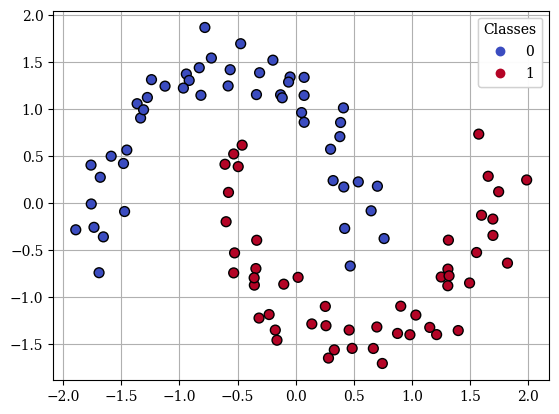

In [2]:
X, y = datasets.make_moons(100, noise=.1, random_state=42)
X = (X - X.mean(0)) / X.std(0)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()

train_ds = torch.utils.data.TensorDataset(X, y)

plot_dset(X_l=X, y_l=y)
plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  | Name          | Type              | Params
----------------------------------------------------
0 | model         | ModuleList        | 34.3 K
1 | loss_fn       | CrossEntropyLoss  | 0     
2 | train_metrics | ModuleDict        | 0     
3 | val_metrics   | ModuleDict        | 0     
4 | val_loss_fn   | GibbsCrossEntropy | 0     
----------------------------------------------------
34.3 K    Trainable params
0         Non-trainable params
34.3 K    Total params
0.137     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


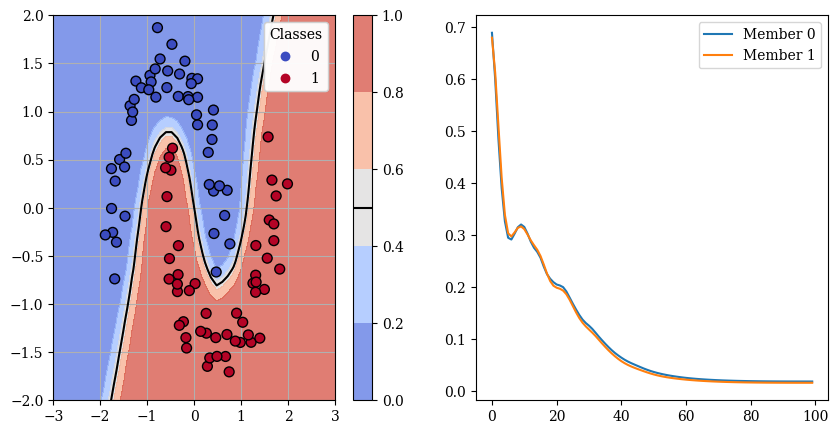

In [3]:
num_members = 2
num_epochs = 100
torch.manual_seed(0)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)

members = [Net(2) for _ in range(num_members)]
optimizers = [torch.optim.SGD(m.parameters(), lr=1e-1, momentum=0.9) for m in members]
lr_schedulers = [torch.optim.lr_scheduler.CosineAnnealingLR(o, T_max=100) for o in optimizers]
model = EnsembleModel(members, optimizer_list=optimizers, lr_scheduler_list=lr_schedulers)
history = MetricHistory()
trainer = L.Trainer(max_epochs=num_epochs, callbacks=[history], enable_checkpointing=False)
trainer.fit(model, train_dataloaders=train_loader) #TODO(dhuseljic): Why does including a validation dataloader lead to numerous empty prints?

model.eval()
plt.figure(figsize=(10, 5))
plot_contour(model, X_l=X, y_l=y, ax=plt.subplot(121), forward_mode='mc', x_domain=(-3, 3), y_domain=(-2, 2))
plt.subplot(122)
plt.legend()
for i in range(num_members):
    plt.plot([d[f'train_loss_member{i}'] for d in history], label=f'Member {i}')
plt.legend()
plt.show()